# Keypoint MoSeq for Home Cage SLEAP Data

This notebook uses the home-cage SLEAP organization already used in `Pose_Tracking`.

- TDT trial folders define `subject_name`
- SLEAP `.analysis.h5` files are matched by `subject_name`
- each SLEAP track (`subject`, `agent`) is exported as its own Keypoint MoSeq recording

The helper functions live in `keypoint_moseq_utils.py`.

In [1]:
import os
import sys
from pathlib import Path

import pandas as pd

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "Pose_Tracking":
    POSE_TRACKING_DIR = PROJECT_ROOT
else:
    POSE_TRACKING_DIR = PROJECT_ROOT / "Pose_Tracking"

if str(POSE_TRACKING_DIR) not in sys.path:
    sys.path.insert(0, str(POSE_TRACKING_DIR))

from keypoint_moseq_utils import (
    build_home_cage_dataset,
    load_kpms_inputs,
    results_to_frame_table,
    save_kpms_inputs,
)


## Paths and Settings

Fill in the directories for your home-cage experiment.

In [2]:
experiment_dir = Path(r"C:\Users\alber\OneDrive\Desktop\PC_Lab\Photometry\Pilot_2\Combined_Cohorts\Home_Cage\SLEAP\all_tdt")
behavior_dir = Path(r"C:\Users\alber\OneDrive\Desktop\PC_Lab\Photometry\Pilot_2\Combined_Cohorts\Home_Cage\SLEAP\all_csvs")
sleap_dir = Path(r"C:\Users\alber\OneDrive\Desktop\PC_Lab\Photometry\Pilot_2\Combined_Cohorts\Home_Cage\SLEAP\sleap_id_corrected")
video_dir = Path(r"C:\Users\alber\OneDrive\Desktop\PC_Lab\Photometry\Pilot_2\Combined_Cohorts\Home_Cage\SLEAP\HC_Videos_Only")
project_dir = POSE_TRACKING_DIR / "keypoint_moseq_project_home_cage"

fps = 10.0
include_tracks = ("subject", "agent")

# Set True if you want each manual social bout exported as its own recording.
use_bouts = False

# Default bodypart handling for fitting.
exclude_bodyparts = ["Tail_Base"]
anterior_bodyparts = ["Nose"]
posterior_bodyparts = ["Head"]

project_dir.mkdir(parents=True, exist_ok=True)
project_dir


WindowsPath('c:/Users/alber/OneDrive/Documents/GitHub/Fiber_Photometry_revisions/Pose_Tracking/keypoint_moseq_project_home_cage')

## Export Keypoint MoSeq Inputs

This reads the SLEAP files directly and packages them for Keypoint MoSeq.

In [3]:
coordinates, confidences, bodyparts, skeleton, metadata_df = build_home_cage_dataset(
    experiment_dir=str(experiment_dir),
    sleap_dir=str(sleap_dir),
    fps=fps,
    include_tracks=include_tracks,
    use_bouts=use_bouts,
    behavior_dir=str(behavior_dir) if use_bouts else None,
)

inputs_path = project_dir / "home_cage_kpms_inputs.pkl"
metadata_path = project_dir / "recording_metadata.csv"

save_kpms_inputs(
    output_path=str(inputs_path),
    coordinates=coordinates,
    confidences=confidences,
    bodyparts=bodyparts,
    skeleton=skeleton,
    metadata_df=metadata_df,
)
metadata_df.to_csv(metadata_path, index=False)

print(f"Saved inputs to: {inputs_path}")
print(f"Saved metadata to: {metadata_path}")
print(f"Recordings exported: {len(coordinates)}")
metadata_df.head()


Saved inputs to: c:\Users\alber\OneDrive\Documents\GitHub\Fiber_Photometry_revisions\Pose_Tracking\keypoint_moseq_project_home_cage\home_cage_kpms_inputs.pkl
Saved metadata to: c:\Users\alber\OneDrive\Documents\GitHub\Fiber_Photometry_revisions\Pose_Tracking\keypoint_moseq_project_home_cage\recording_metadata.csv
Recordings exported: 50


,recording_name,subject_name,trial_name,track_name,source_h5,n_frames,fps,bout_name,bout_start_s,bout_end_s
0,n5_subject,n5,n5-240823-085032,subject,C:\Users\alber\OneDrive\Desktop\PC_Lab\Photome...,17728,10.0,None,None,None
1,n5_agent,n5,n5-240823-085032,agent,C:\Users\alber\OneDrive\Desktop\PC_Lab\Photome...,17728,10.0,None,None,None
2,n6_subject,n6,n6-240823-101436,subject,C:\Users\alber\OneDrive\Desktop\PC_Lab\Photome...,17796,10.0,None,None,None
3,n6_agent,n6,n6-240823-101436,agent,C:\Users\alber\OneDrive\Desktop\PC_Lab\Photome...,17796,10.0,None,None,None
4,n7_subject,n7,n7-240824-062103,subject,C:\Users\alber\OneDrive\Desktop\PC_Lab\Photome...,18391,10.0,None,None,None


In [4]:
sorted(bodyparts), skeleton[:10]


(['Center',
  'Head',
  'Left_Ear',
  'Left_Lateral',
  'Neck',
  'Nose',
  'Right_Ear',
  'Right_Lateral',
  'Tail_Base'],
 [['Tail_Base', 'Left_Lateral'],
  ['Tail_Base', 'Right_Lateral'],
  ['Tail_Base', 'Center'],
  ['Center', 'Right_Lateral'],
  ['Center', 'Left_Lateral'],
  ['Center', 'Neck'],
  ['Neck', 'Right_Lateral'],
  ['Neck', 'Left_Lateral'],
  ['Neck', 'Head'],
  ['Head', 'Nose']])

## Review the Exported Recordings

Each recording is a single animal track, optionally split by bout.

In [5]:
metadata_df.groupby(["track_name", "subject_name"]).agg(
    n_recordings=("recording_name", "count"),
    total_frames=("n_frames", "sum"),
).reset_index().head(20)


,track_name,subject_name,n_recordings,total_frames
0,agent,n5,1,17728
1,agent,n6,1,17796
2,agent,n7,1,18391
3,agent,nn1,1,18338
4,agent,nn2,1,17740
5,agent,nn3,1,18568
6,agent,nn4,1,18617
7,agent,nn5,1,17728
8,agent,nn6,1,17796
9,agent,nn7,1,18391


## Load Keypoint MoSeq

Run this only after installing `keypoint_moseq` in the Python environment backing this notebook.

In [6]:
import keypoint_moseq as kpms

payload = load_kpms_inputs(str(inputs_path))
coordinates = payload["coordinates"]
confidences = payload["confidences"]
bodyparts = payload["bodyparts"]
skeleton = payload["skeleton"]
metadata_df = payload["metadata_df"]

print(f"Loaded {len(coordinates)} recordings for Keypoint MoSeq")


Loaded 50 recordings for Keypoint MoSeq


## Set Up the Keypoint MoSeq Project

In [7]:
config_path = project_dir / "config.yml"

if not config_path.exists():
    print(f"No config found at {config_path}. Creating a default config first.")
    kpms.setup_project(
        str(project_dir),
        bodyparts=bodyparts,
        skeleton=skeleton,
        use_bodyparts=bodyparts,
        anterior_bodyparts=anterior_bodyparts,
        posterior_bodyparts=posterior_bodyparts,
        video_dir=str(video_dir),
        fps=fps,
        overwrite=True,
    )
else:
    print(f"Using existing config: {config_path}")

use_bodyparts = [bp for bp in bodyparts if bp not in exclude_bodyparts]
missing_anterior = [bp for bp in anterior_bodyparts if bp not in use_bodyparts]
missing_posterior = [bp for bp in posterior_bodyparts if bp not in use_bodyparts]

if missing_anterior or missing_posterior:
    raise ValueError(
        "Chosen anterior/posterior bodyparts must also be present in use_bodyparts. "
        f"Missing anterior: {missing_anterior}; missing posterior: {missing_posterior}"
    )

kpms.update_config(
    str(project_dir),
    bodyparts=bodyparts,
    skeleton=skeleton,
    video_dir=str(video_dir),
    anterior_bodyparts=anterior_bodyparts,
    posterior_bodyparts=posterior_bodyparts,
    use_bodyparts=use_bodyparts,
    fps=fps,
    latent_dim=10,
)

config = kpms.load_config(str(project_dir))
config


Using existing config: c:\Users\alber\OneDrive\Documents\GitHub\Fiber_Photometry_revisions\Pose_Tracking\keypoint_moseq_project_home_cage\config.yml


{'bodyparts': ['Head',
  'Right_Ear',
  'Nose',
  'Tail_Base',
  'Left_Lateral',
  'Right_Lateral',
  'Left_Ear',
  'Neck',
  'Center'],
 'use_bodyparts': ['Head',
  'Right_Ear',
  'Nose',
  'Left_Lateral',
  'Right_Lateral',
  'Left_Ear',
  'Neck',
  'Center'],
 'skeleton': [['Tail_Base', 'Left_Lateral'],
  ['Tail_Base', 'Right_Lateral'],
  ['Tail_Base', 'Center'],
  ['Center', 'Right_Lateral'],
  ['Center', 'Left_Lateral'],
  ['Center', 'Neck'],
  ['Neck', 'Right_Lateral'],
  ['Neck', 'Left_Lateral'],
  ['Neck', 'Head'],
  ['Head', 'Nose'],
  ['Nose', 'Right_Ear'],
  ['Nose', 'Left_Ear'],
  ['Right_Ear', 'Left_Ear'],
  ['Head', 'Right_Ear'],
  ['Head', 'Left_Ear']],
 'anterior_bodyparts': ['Nose'],
 'posterior_bodyparts': ['Head'],
 'added_noise_level': 0.1,
 'PCA_fitting_num_frames': 1000000,
 'conf_threshold': 0.5,
 'error_estimator': {'intercept': 0.25, 'slope': -0.5},
 'obs_hypparams': {'nu_s': 5,
  'nu_sigma': 100000.0,
  'sigmasq_0': 0.1,
  'sigmasq_C': 0.1},
 'ar_hypparams': {

## Optional Outlier Removal

In [8]:
run_outlier_removal = True

if run_outlier_removal:
    coordinates, confidences = kpms.outlier_removal(
        coordinates,
        confidences,
        str(project_dir),
        overwrite=False,
        **config,
    )


## Format Data and Fit PCA

In [9]:
data, metadata = kpms.format_data(coordinates, confidences, **config)
pca = kpms.fit_pca(**data, **config)
kpms.save_pca(pca, str(project_dir))
pca


,n_components,None
,copy,True
,whiten,False
,svd_solver,'auto'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,42


## Fit the Model

The two-stage fit below mirrors the command-line script setup.

Resuming 2026_04_28-12_42_32 from iteration 525
Outputs will be saved to c:\Users\alber\OneDrive\Documents\GitHub\Fibe
r_Photometry_revisions\Pose_Tracking\keypoint_moseq_project_home_cage\
2026_04_28-12_42_32


 95%|█████████████████████████████████▏ | 18/19 [24:15<01:15, 75.13s/it]

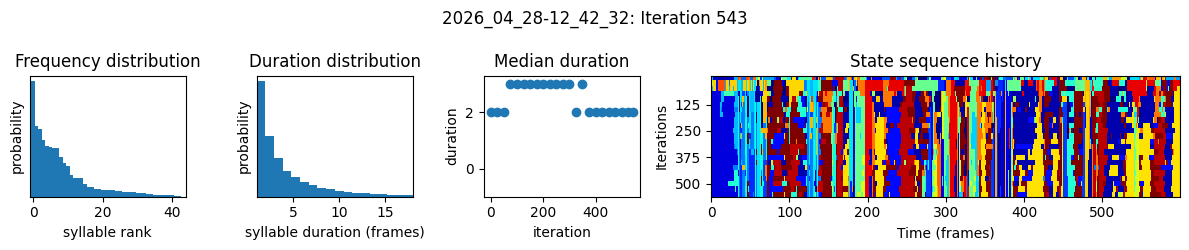

100%|███████████████████████████████████| 19/19 [25:29<00:00, 80.51s/it]


In [10]:
import keypoint_moseq as kpms

model_name = "2026_04_28-12_42_32"
additional_iters = 18  # change if you want more or fewer iterations

model, data, metadata, current_iter = kpms.load_checkpoint(
    str(project_dir),
    model_name,
)

print("Resuming", model_name, "from iteration", current_iter)

model = kpms.update_hypparams(model, kappa=1e4)

model = kpms.fit_model(
    model,
    data,
    metadata,
    str(project_dir),
    model_name,
    ar_only=False,
    start_iter=current_iter,
    num_iters=current_iter + additional_iters,
)[0]


Outputs will be saved to c:\Users\alber\OneDrive\Documents\GitHub\Fibe
r_Photometry_revisions\Pose_Tracking\keypoint_moseq_project_home_cage\
2026_04_28-12_42_32


 49%|█████████████████▏                 | 25/51 [09:14<09:27, 21.82s/it]

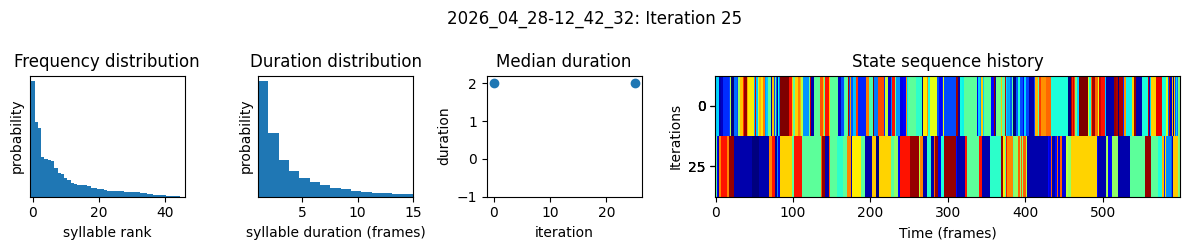

 98%|██████████████████████████████████▎| 50/51 [20:13<00:26, 26.62s/it]

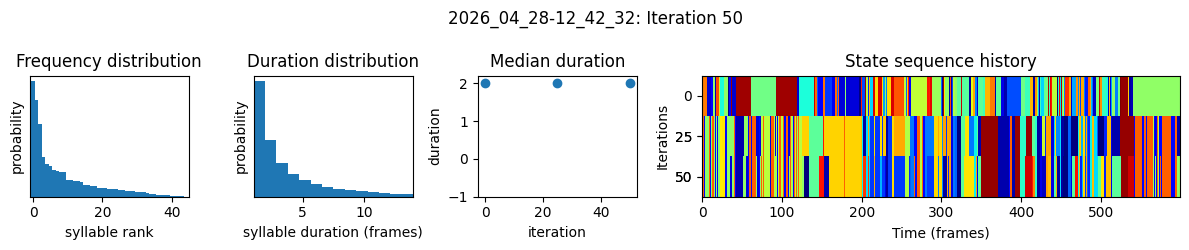

100%|███████████████████████████████████| 51/51 [20:39<00:00, 24.30s/it]


Outputs will be saved to c:\Users\alber\OneDrive\Documents\GitHub\Fibe
r_Photometry_revisions\Pose_Tracking\keypoint_moseq_project_home_cage\
2026_04_28-12_42_32


  5%|█▌                             | 25/501 [42:11<12:44:57, 96.42s/it]

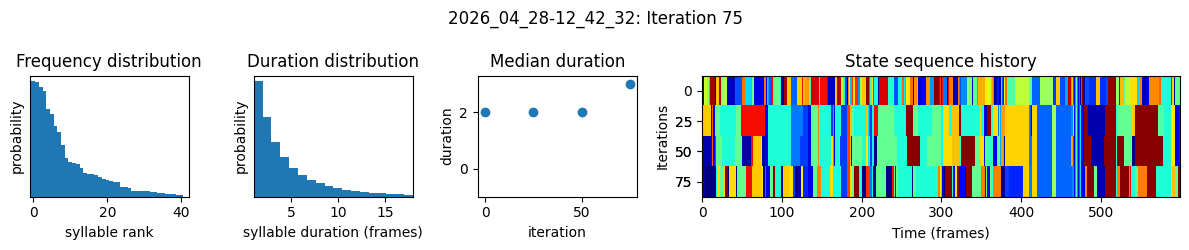

 10%|██▉                          | 50/501 [1:20:13<12:13:20, 97.56s/it]

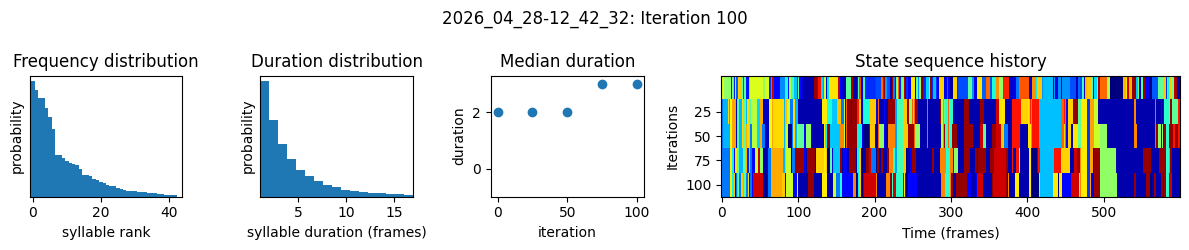

 15%|████▎                        | 75/501 [2:00:57<11:06:20, 93.85s/it]

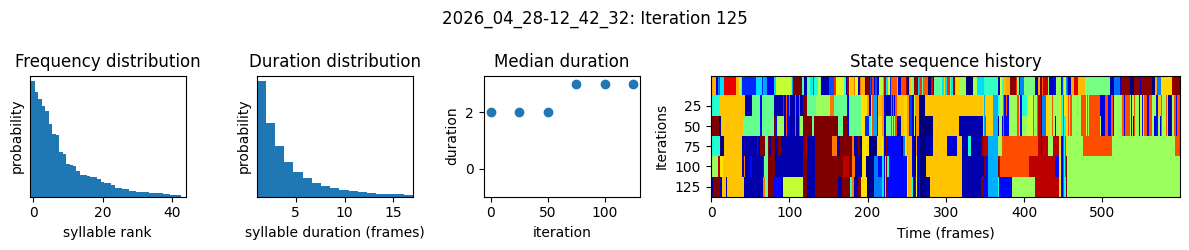

 20%|█████▊                       | 100/501 [2:36:34<9:03:25, 81.31s/it]

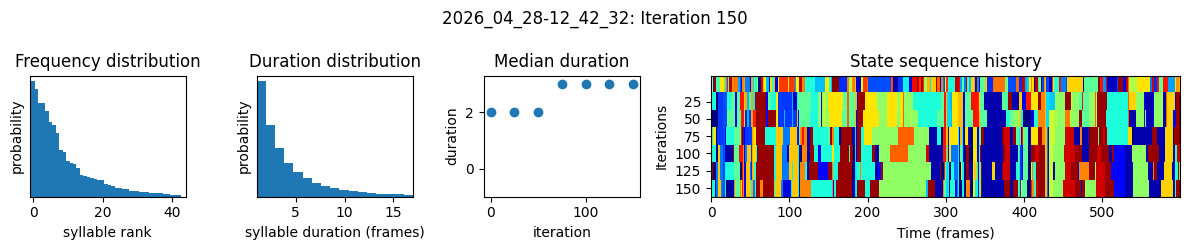

 25%|███████▏                     | 125/501 [3:09:51<8:10:55, 78.34s/it]

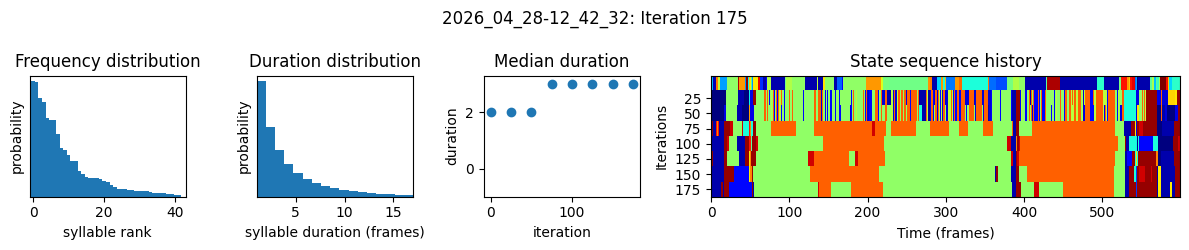

 30%|████████▋                    | 150/501 [3:43:22<7:40:18, 78.69s/it]

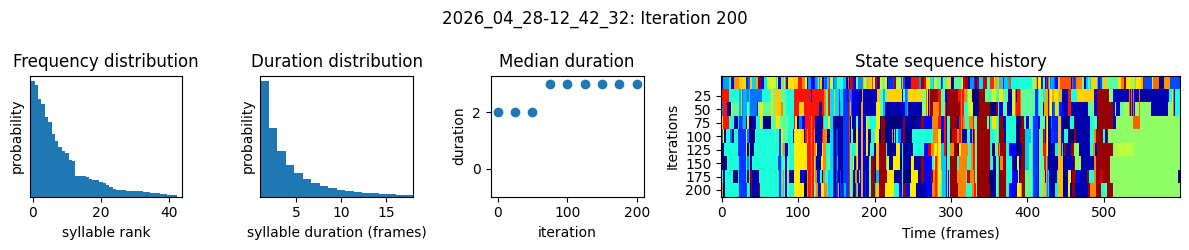

 35%|██████████▏                  | 175/501 [4:16:38<7:14:29, 79.97s/it]

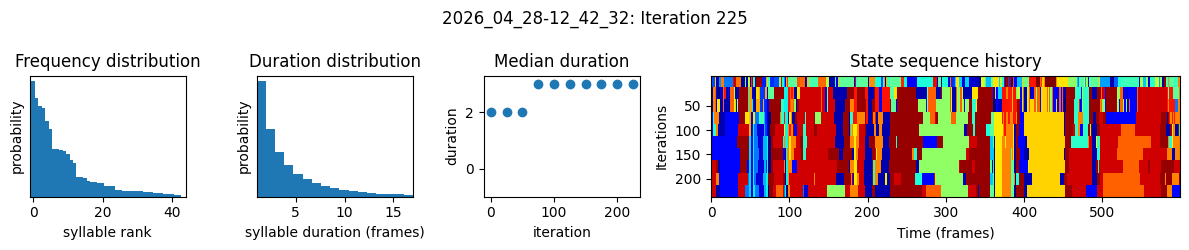

 40%|███████████▌                 | 200/501 [4:50:15<6:18:13, 75.39s/it]

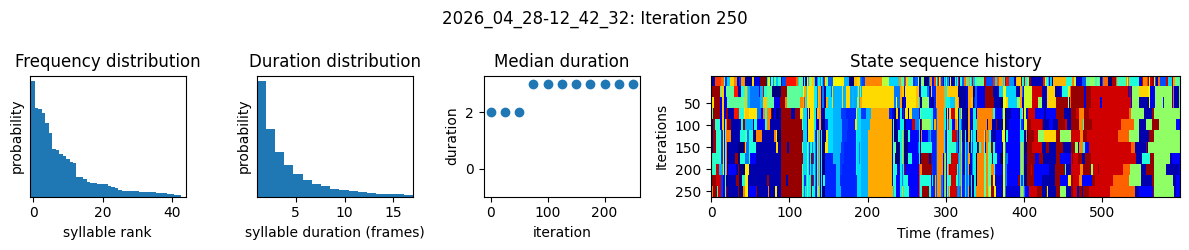

 45%|███████████▏             | 225/501 [7:47:17<145:47:58, 1901.74s/it]

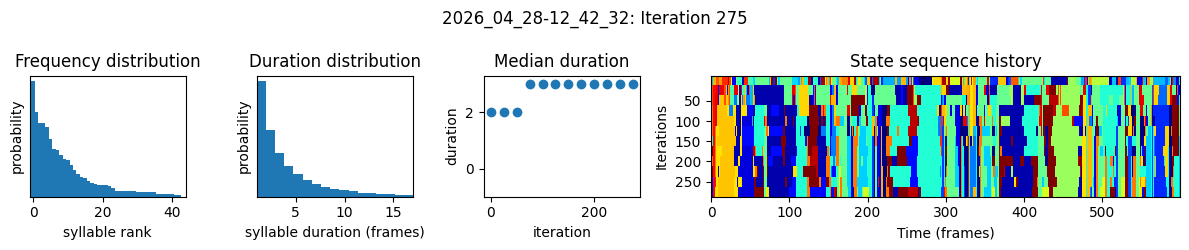

 50%|██████████████▍              | 250/501 [8:20:12<5:32:05, 79.39s/it]

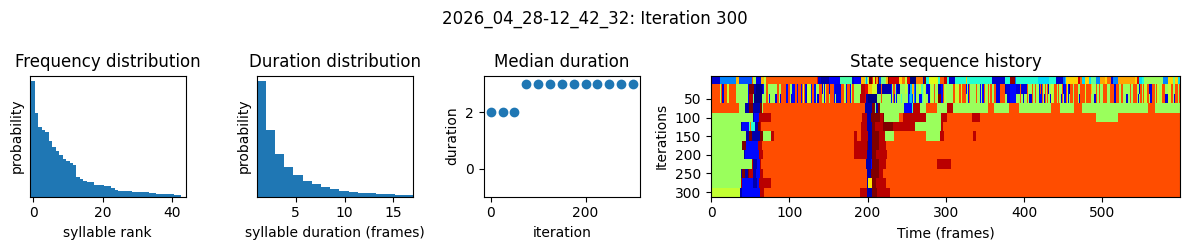

 55%|███████████████▉             | 275/501 [8:52:00<4:38:19, 73.89s/it]

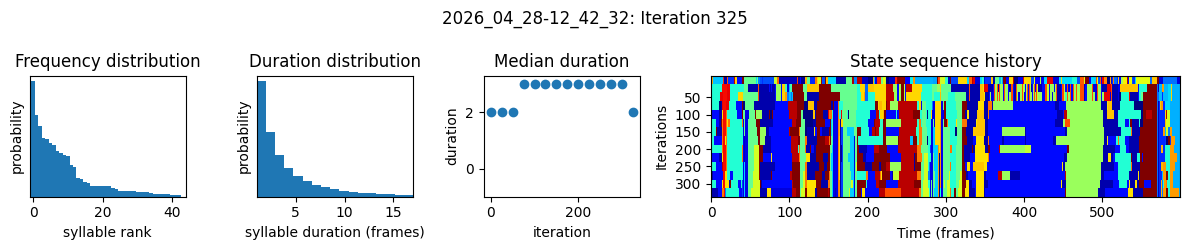

 60%|█████████████████▎           | 300/501 [9:23:39<4:25:24, 79.22s/it]

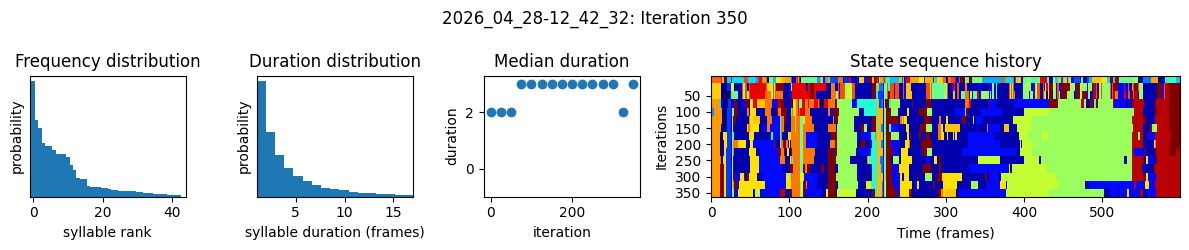

 65%|██████████████████▊          | 325/501 [9:55:31<3:37:32, 74.16s/it]

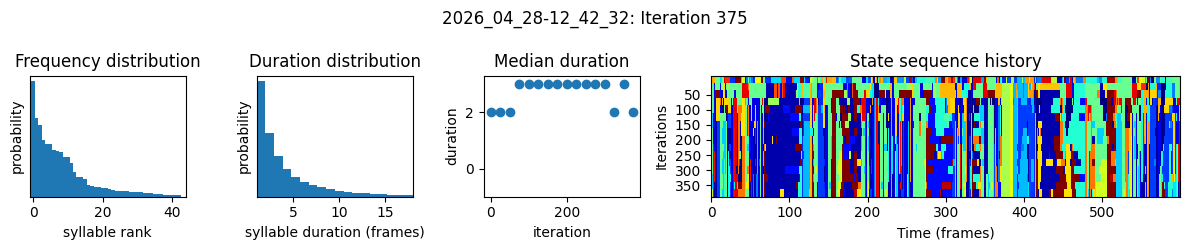

 70%|███████████████████▌        | 350/501 [10:28:32<3:21:50, 80.20s/it]

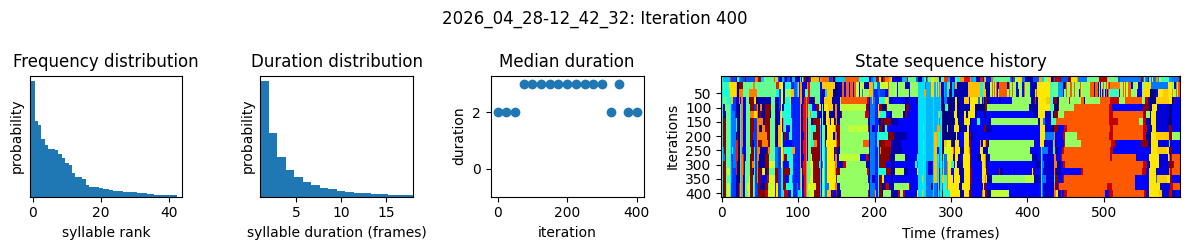

 75%|████████████████████▉       | 375/501 [11:01:27<2:35:27, 74.03s/it]

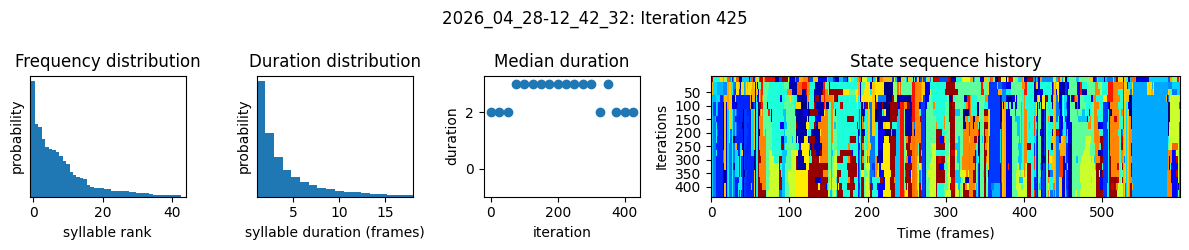

 80%|██████████████████████▎     | 400/501 [11:33:00<2:11:53, 78.35s/it]

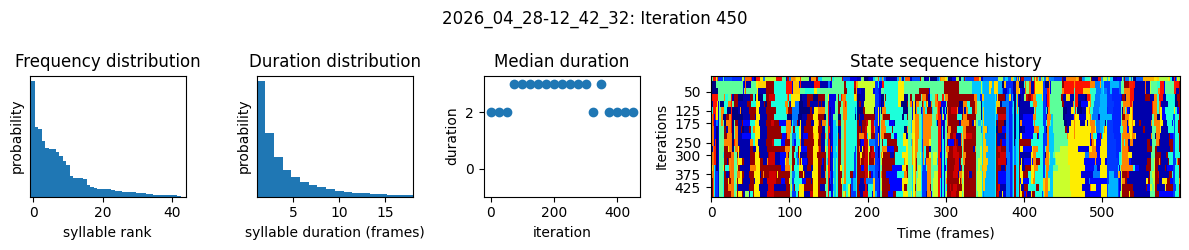

 85%|███████████████████████▊    | 425/501 [12:05:50<1:39:31, 78.58s/it]

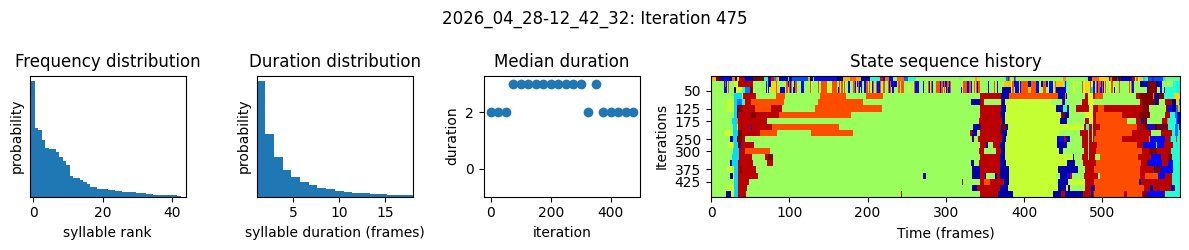

 90%|█████████████████████████▏  | 450/501 [12:38:47<1:06:50, 78.64s/it]

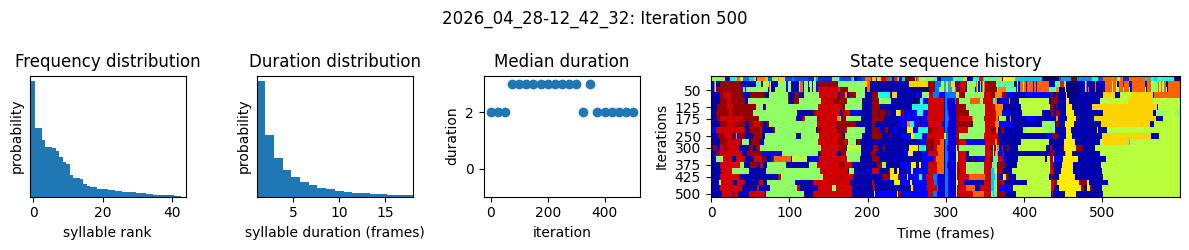

 95%|████████████████████████████▍ | 475/501 [13:11:38<34:04, 78.62s/it]

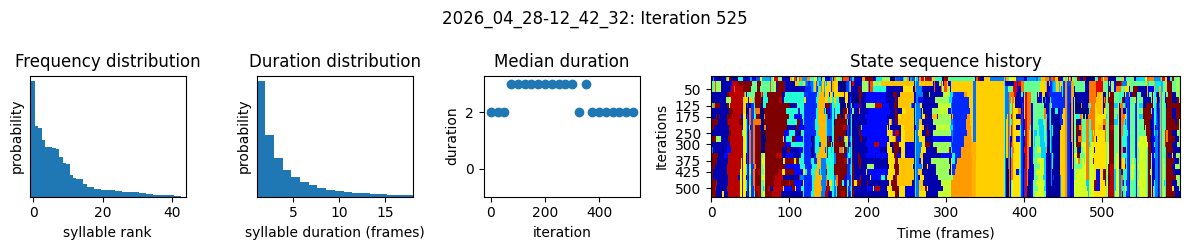

 97%|█████████████████████████████ | 485/501 [13:24:49<21:02, 78.91s/it]

In [ ]:
# model_name = None
# num_ar_iters = 50
# num_full_iters = 500

# model = kpms.init_model(data, pca=pca, **config)
# model = kpms.update_hypparams(model, kappa=1e6)
# model, model_name = kpms.fit_model(
#     model,
#     data,
#     metadata,
#     str(project_dir),
#     model_name=model_name,
#     ar_only=True,
#     num_iters=num_ar_iters,
# )

# model, data, metadata, current_iter = kpms.load_checkpoint(
#     str(project_dir),
#     model_name,
#     iteration=num_ar_iters,
# )
# model = kpms.update_hypparams(model, kappa=1e4)
# model = kpms.fit_model(
#     model,
#     data,
#     metadata,
#     str(project_dir),
#     model_name,
#     ar_only=False,
#     start_iter=current_iter,
#     num_iters=current_iter + num_full_iters,
# )[0]

# model_name


## Extract Syllables and Save a Frame Table

In [11]:
kpms.reindex_syllables_in_checkpoint(str(project_dir), model_name)
model, data, metadata, _ = kpms.load_checkpoint(str(project_dir), model_name)
results = kpms.extract_results(model, metadata, str(project_dir), model_name)
kpms.save_results_as_csv(results, str(project_dir), model_name)

syllable_frames = results_to_frame_table(results, metadata_df)
syllable_frames_path = project_dir / model_name / "syllable_frames.csv"
syllable_frames.to_csv(syllable_frames_path, index=False)

print(f"Saved frame table to: {syllable_frames_path}")
syllable_frames.head()


Reindexing: 100%|███████████| 23/23 [00:09<00:00,  2.55model snapshot/s]


Saved results to c:\Users\alber\OneDrive\Documents\GitHub\Fiber_Photom
etry_revisions\Pose_Tracking\keypoint_moseq_project_home_cage\2026_04_
28-12_42_32\results.h5


Saving to csv: 100%|████████████████████| 50/50 [00:05<00:00,  8.56it/s]


Saved frame table to: c:\Users\alber\OneDrive\Documents\GitHub\Fiber_Photometry_revisions\Pose_Tracking\keypoint_moseq_project_home_cage\2026_04_28-12_42_32\syllable_frames.csv


,recording_name,frame_index,syllable,time_s,centroid_x,centroid_y,heading,subject_name,trial_name,track_name,source_h5,n_frames,fps,bout_name,bout_start_s,bout_end_s
0,n7_agent,0,33,0.0,166.257176,285.601688,1.048880,n7,n7-240824-062103,agent,C:\Users\alber\OneDrive\Desktop\PC_Lab\Photome...,18391,10.0,None,None,None
1,n7_agent,1,33,0.1,166.198562,286.359458,0.638477,n7,n7-240824-062103,agent,C:\Users\alber\OneDrive\Desktop\PC_Lab\Photome...,18391,10.0,None,None,None
2,n7_agent,2,33,0.2,165.575059,285.845087,-0.998857,n7,n7-240824-062103,agent,C:\Users\alber\OneDrive\Desktop\PC_Lab\Photome...,18391,10.0,None,None,None
3,n7_agent,3,33,0.3,166.360241,286.502258,-3.040587,n7,n7-240824-062103,agent,C:\Users\alber\OneDrive\Desktop\PC_Lab\Photome...,18391,10.0,None,None,None
4,n7_agent,4,33,0.4,167.894677,286.723288,-0.686688,n7,n7-240824-062103,agent,C:\Users\alber\OneDrive\Desktop\PC_Lab\Photome...,18391,10.0,None,None,None


## Quick Summaries

In [12]:
syllable_frames.groupby(["track_name", "syllable"]).size().reset_index(name="n_frames").sort_values(
    ["track_name", "n_frames"], ascending=[True, False]
).head(20)


,track_name,syllable,n_frames
33,agent,33,69061
0,agent,0,63578
4,agent,4,41023
10,agent,10,33755
7,agent,7,31770
3,agent,3,28196
5,agent,5,28134
2,agent,2,21943
11,agent,11,17293
9,agent,9,14667


In [13]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np


def generate_selected_trajectory_plots(
    coordinates,
    results,
    output_dir,
    selected_syllables,
    *,
    pre=0.167,
    post=0.5,
    min_frequency=0.0,
    min_duration=3,
    skeleton=None,
    bodyparts=None,
    use_bodyparts=None,
    keypoint_colormap="autumn",
    plot_options=None,
    get_limits_pctl=0,
    padding=None,
    lims=None,
    save_gifs=True,
    save_mp4s=False,
    fps=None,
    density_sample=False,
    sampling_options=None,
):
    if fps is None:
        raise ValueError("fps must be provided")

    plot_options = dict(plot_options or {})
    plot_options.update({"keypoint_colormap": keypoint_colormap})
    padding = padding or {"left": 0.1, "right": 0.1, "top": 0.2, "bottom": 0.2}
    sampling_options = dict(sampling_options or {"n_neighbors": 50})
    skeleton = skeleton or []

    pre_frames = round(pre * fps)
    post_frames = round(post * fps)
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    edges = [] if len(skeleton) == 0 else kpms.get_edges(use_bodyparts, skeleton)
    typical_trajectories = kpms.get_typical_trajectories(
        coordinates,
        results,
        pre_frames,
        post_frames,
        min_frequency,
        min_duration,
        bodyparts,
        use_bodyparts,
        density_sample,
        sampling_options,
    )

    requested_syllables = [int(s) for s in selected_syllables]
    syllable_ixs = [s for s in requested_syllables if s in typical_trajectories]
    missing_syllables = [s for s in requested_syllables if s not in typical_trajectories]

    if not syllable_ixs:
        raise ValueError("None of the requested syllables had usable trajectories.")

    titles = [f"Syllable{s}" for s in syllable_ixs]
    Xs = np.stack([typical_trajectories[s] for s in syllable_ixs])

    if Xs.shape[-1] != 2:
        raise ValueError("This helper currently expects 2D trajectories.")

    Xs_2D = Xs * np.array([1, -1])
    if lims is None:
        lims = kpms.get_limits(Xs_2D, pctl=get_limits_pctl, **padding)

    for title, X in zip(titles, Xs_2D):
        fig, ax, rasters = kpms.plot_trajectories(
            [title],
            X[None],
            lims,
            edges=edges,
            return_rasters=(save_gifs or save_mp4s),
            **plot_options,
        )
        fig.savefig(output_dir / f"{title}.pdf")
        plt.close(fig)

        if save_gifs:
            frame_duration = (pre_frames + post_frames) / len(rasters) / fps
            kpms.save_gif(rasters, output_dir / f"{title}.gif", duration=frame_duration)
        if save_mp4s:
            use_fps = len(rasters) / (pre_frames + post_frames) * fps
            kpms.write_video_clip(rasters, output_dir / f"{title}.mp4", fps=use_fps)

    fig, ax, rasters = kpms.plot_trajectories(
        titles,
        Xs_2D,
        lims,
        edges=edges,
        return_rasters=(save_gifs or save_mp4s),
        **plot_options,
    )
    fig.savefig(output_dir / "all_trajectories.pdf")
    plt.show()

    if save_gifs:
        frame_duration = (pre_frames + post_frames) / len(rasters) / fps
        kpms.save_gif(rasters, output_dir / "all_trajectories.gif", duration=frame_duration)
    if save_mp4s:
        use_fps = len(rasters) / (pre_frames + post_frames) * fps
        kpms.write_video_clip(rasters, output_dir / "all_trajectories.mp4", fps=use_fps)

    print(f"Saved {len(syllable_ixs)} syllable plots to {output_dir}")
    if missing_syllables:
        print(f"Skipped {len(missing_syllables)} requested syllables with no usable trajectory: {missing_syllables}")

    return syllable_ixs


TypeError: 'dict' object is not callable

Saving trajectory plots to C:\Users\alber\OneDrive\Documents\GitHub\Fiber_Photometry_revisions\Pose_Tracking\keypoint_moseq_project_home_cage\2026_04_28-12_42_32\trajectory_plots


Generating trajectory plots: 100%|██████| 30/30 [00:15<00:00,  1.94it/s]


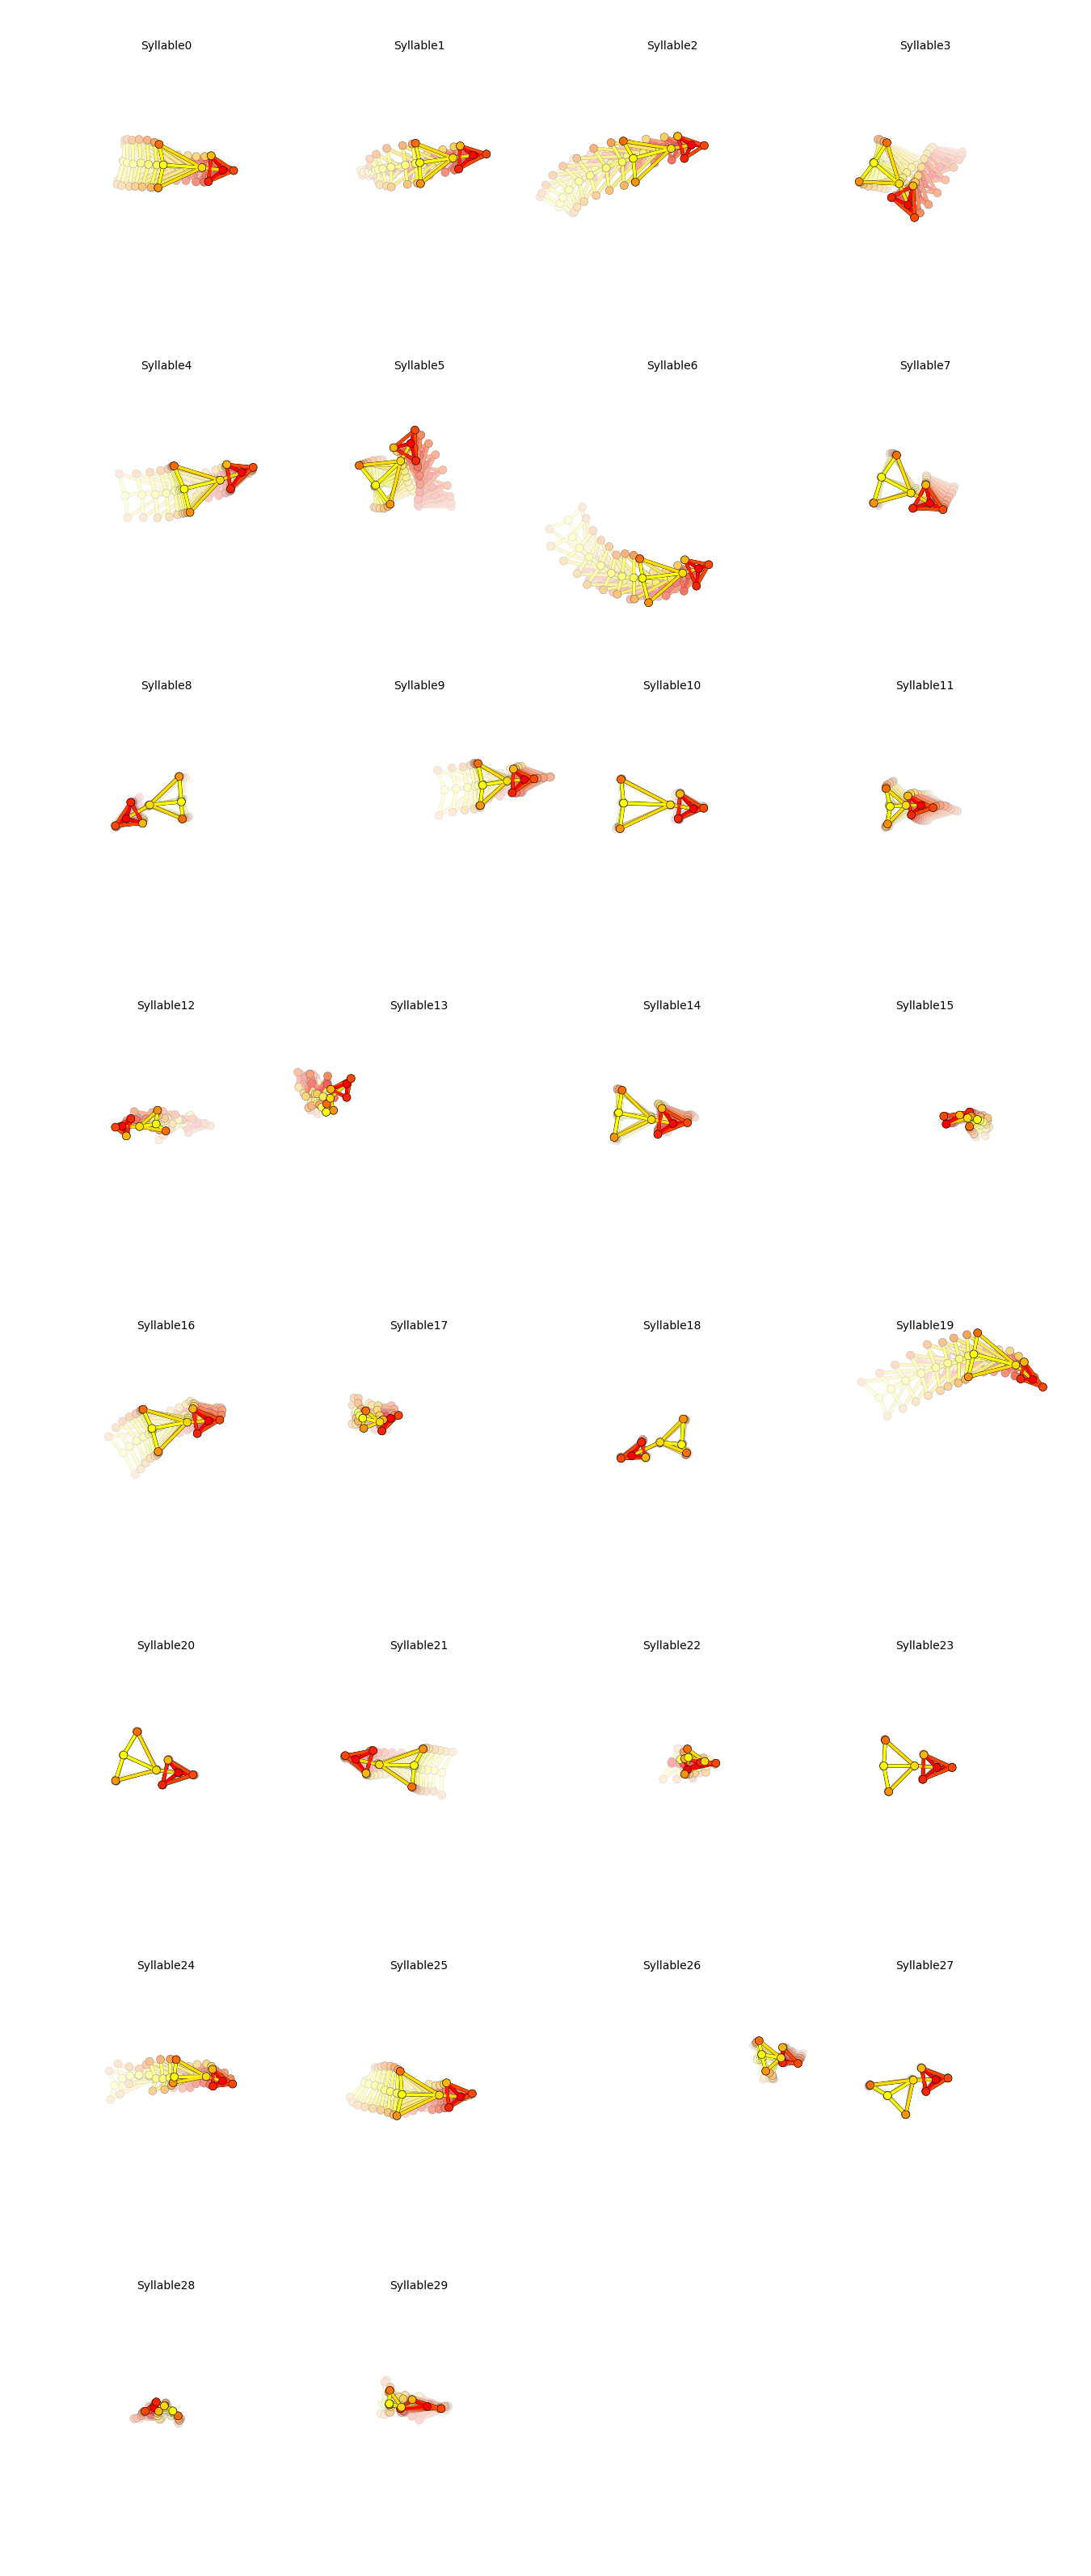

In [15]:
import keypoint_moseq as kpms

project_dir = Path(r"C:\Users\alber\OneDrive\Documents\GitHub\Fiber_Photometry_revisions\Pose_Tracking\keypoint_moseq_project_home_cage")
model_name = "2026_04_28-12_42_32"

config = lambda: kpms.load_config(str(project_dir))

# If needed: reload the exported inputs
payload = load_kpms_inputs(project_dir / "home_cage_kpms_inputs.pkl")
coordinates = payload["coordinates"]

# Load results if they were already saved
results = kpms.load_results(str(project_dir), model_name)


Saving trajectory plots to C:\Users\alber\OneDrive\Documents\GitHub\Fiber_Photometry_revisions\Pose_Tracking\keypoint_moseq_project_home_cage\2026_04_28-12_42_32\trajectory_plots_custom


Generating trajectory plots: 100%|██████| 30/30 [00:17<00:00,  1.69it/s]


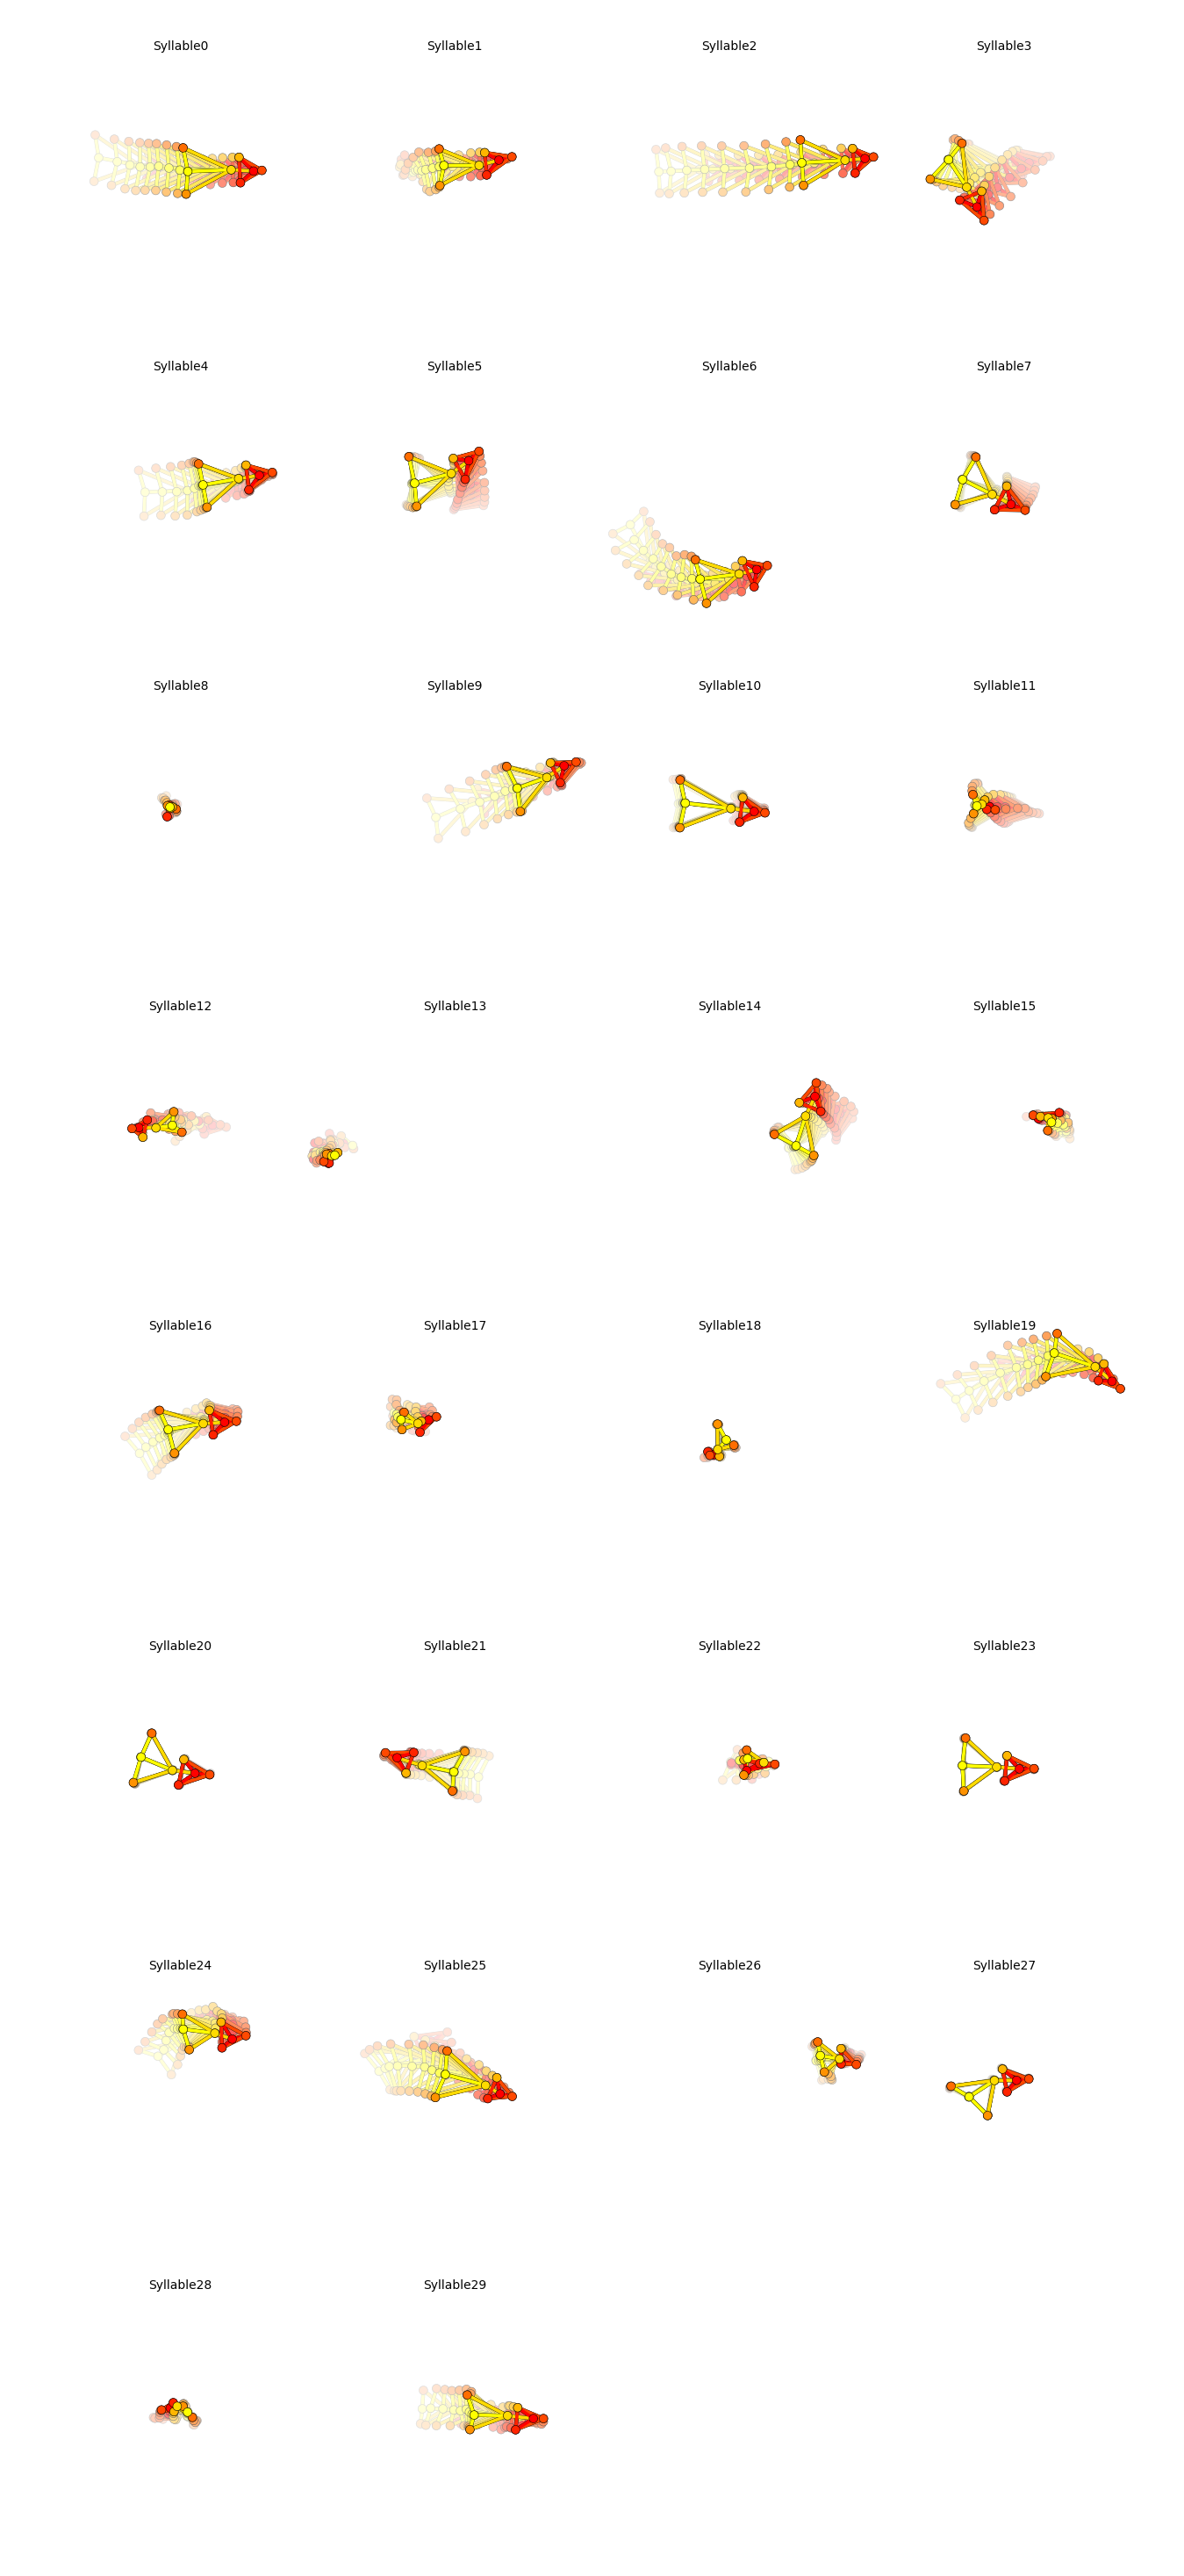

In [16]:
selected_syllables = list(range(49))

generated_syllables = generate_selected_trajectory_plots(
    coordinates,
    results,
    output_dir=project_dir / model_name / "trajectory_plots_custom",
    selected_syllables=selected_syllables,
    min_frequency=0.0,
    density_sample=False,
    **config(),
)

generated_syllables
